In [5]:
import subprocess
import networkx as nx
import pynauty as nauty
from collections import Counter
import math
import io

def get_exact_distribution_from_geng(n):
    # geng n -q: generates all non-isomorphic graphs silently
    process = subprocess.Popen(
        ['geng', str(n), '-q'], 
        stdout=subprocess.PIPE, 
        text=True
    )
    
    distribution = Counter()
    n_fact = math.factorial(n)
    
    print(f"Streaming and analyzing graphs for n={n}...")
    
    for line in process.stdout:
        g6_str = line.strip()
        if not g6_str: continue
        
        # 1. Get graph invariants
        G = nx.from_graph6_bytes(g6_str.encode())
        m = G.number_of_edges()
        tris = nx.triangles(G)
        t = sum(tris.values()) // 3
        t2 = sum(count**2 for count in tris.values())
        
        # 2. Calculate Automorphism Group Size using pynauty
        adj_dict = {u: list(v) for u, v in G.adjacency()}
        g_nauty = nauty.Graph(number_of_vertices=n, adjacency_dict=adj_dict)
        res = nauty.autgrp(g_nauty)
        aut_size = int(res[1]) # res[1] is the exact group size
        
        # 3. Apply the weight
        weight = n_fact // aut_size
        distribution[(m, t, t2)] += weight

    process.wait()
    return distribution

n = 10
exact_dist = get_exact_distribution_from_geng(n)
total = 0
print(f"Exact Joint distribution for n={n}:")
for (m, t, t2), count in sorted(exact_dist.items()):
    total += count
    print(f"Edges: {m}, Triangles: {t}, Triangle Squares: {t2} -> Count: {count}")
print(total)


Streaming and analyzing graphs for n=10...
Exact Joint distribution for n=10:
Edges: 0, Triangles: 0, Triangle Squares: 0 -> Count: 1
Edges: 1, Triangles: 0, Triangle Squares: 0 -> Count: 45
Edges: 2, Triangles: 0, Triangle Squares: 0 -> Count: 990
Edges: 3, Triangles: 0, Triangle Squares: 0 -> Count: 14070
Edges: 3, Triangles: 1, Triangle Squares: 3 -> Count: 120
Edges: 4, Triangles: 0, Triangle Squares: 0 -> Count: 143955
Edges: 4, Triangles: 1, Triangle Squares: 3 -> Count: 5040
Edges: 5, Triangles: 0, Triangle Squares: 0 -> Count: 1119699
Edges: 5, Triangles: 1, Triangle Squares: 3 -> Count: 100800
Edges: 5, Triangles: 2, Triangle Squares: 10 -> Count: 1260
Edges: 6, Triangles: 0, Triangle Squares: 0 -> Count: 6823110
Edges: 6, Triangles: 1, Triangle Squares: 3 -> Count: 1266720
Edges: 6, Triangles: 2, Triangle Squares: 6 -> Count: 2100
Edges: 6, Triangles: 2, Triangle Squares: 8 -> Count: 3780
Edges: 6, Triangles: 2, Triangle Squares: 10 -> Count: 49140
Edges: 6, Triangles: 4, Tri

In [6]:
import pandas as pd

# 1. Convert the dictionary items into a list of records
data = [
    {'Edges': m, 'Triangles': t, 'Triangle Squares': t2, 'Count': count} 
    for (m, t, t2), count in exact_dist.items()
]

# 2. Create the DataFrame
df = pd.DataFrame(data)

# 3. (Optional) Sort by Edges and Triangles for cleaner reading
df = df.sort_values(by=['Edges', 'Triangles', 'Triangle Squares'])

# 5. Save to CSV
filename = f't2_joint_distribution_n{n}.csv'
df.to_csv(filename, index=False)

print(f"DataFrame saved to {filename}")
print(df.head())

DataFrame saved to t2_joint_distribution_n10.csv
    Edges  Triangles  Triangle Squares  Count
0       0          0                 0      1
1       1          0                 0     45
2       2          0                 0    990
3       3          0                 0  14070
10      3          1                 3    120


In [1]:
import pandas as pd
n=10
df = pd.read_csv(f't2_joint_distribution_n{n}.csv')
m_star = 17
t_star = 20

df = df.sort_values(by=['Count'], ascending=False)
#print(df.head(20))

filtered_df = df[(df['Edges'] == m_star) & (df['Triangles'] == t_star)]

print(filtered_df.head(10))

      Edges  Triangles  Triangle Squares  Count
1313     17         20               600  78750


In [2]:
exact_dist = {}
for _, row in df.iterrows():
    m = row['Edges']
    t = row['Triangles']
    t2 = row['Triangle Squares']
    count = row['Count']
    exact_dist[(m, t, t2)] = count

In [4]:
import matplotlib.pyplot as plt
import numpy as np

In [5]:
def plot_3d_dist(exact_dist, n, i=None):
    m_vals, t_vals, t2_vals, counts = zip(*[(m, t, t2, c) for (m, t, t2), c in exact_dist.items()])
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    if i is None:
        i = len(m_vals)  # Plot all points
        print(i)
        
    scatter = ax.scatter(m_vals[:i], t_vals[:i], t2_vals[:i], 
                            c=np.log(counts[:i]), cmap='viridis', 
                            s=60, edgecolors='w', linewidth=0.5)

    ax.set_xlabel('Edges (m)')
    ax.set_ylabel('Triangles (t)')
    ax.set_zlabel('Triangle Squares (t2)')
    plt.colorbar(scatter, label='log(Frequency)', pad=0.1)  

    plt.title(f'Joint Distribution of Edges, Triangles, and Triangle Squares (n={n})')
    plt.show()

33292


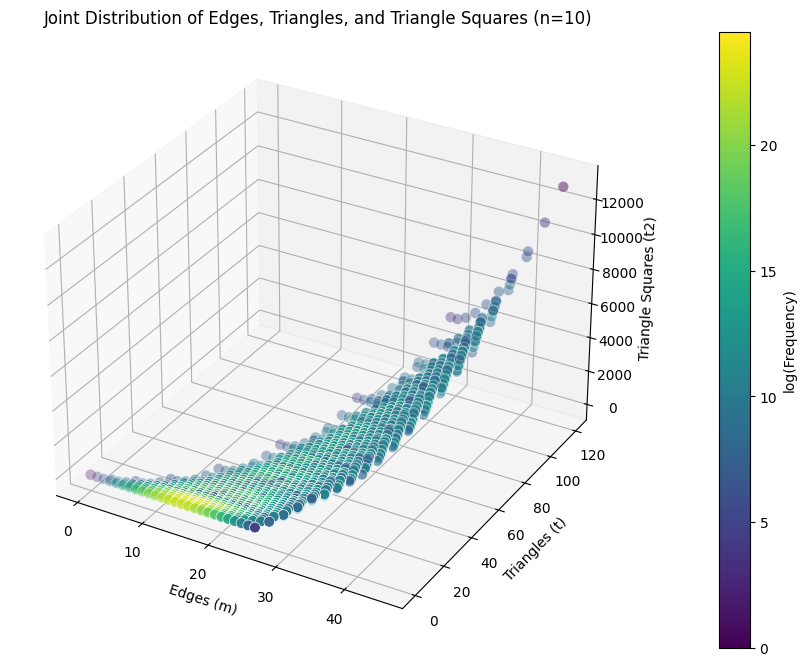

In [6]:
plot_3d_dist(exact_dist, n)


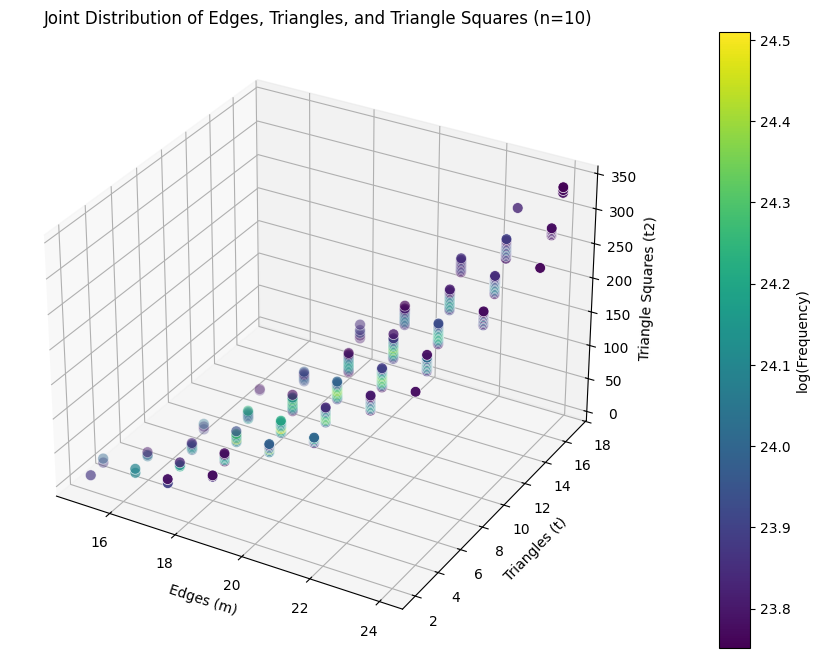

In [6]:
plot_3d_dist(exact_dist, n, i=300)

In [7]:
import numpy as np
from scipy.optimize import root
import mpmath

mpmath.dps = 50
mpmath.mp.dps = 50

def find_ergm_hybrid(n, m_star, t_star, t2_star, exact_dist):
    
    data = np.array([[m, t, t2, count] for (m, t, t2), count in exact_dist.items()], dtype=np.float64)
    m_arr, t_arr, t2_arr, count_arr = data[:, 0], data[:, 1], data[:, 2], data[:, 3]
    log_counts = np.log(count_arr)

    def scipy_equations(vars):
        beta, gamma, delta = vars
        
        log_weights = log_counts - beta * m_arr - gamma * t_arr - delta * t2_arr
        
        max_log_w = np.max(log_weights)
        weights = np.exp(log_weights - max_log_w)
        sum_weights = np.sum(weights)
        
        probs = weights / sum_weights
        
        E_m = np.sum(m_arr * probs)
        E_t = np.sum(t_arr * probs)
        E_t2 = np.sum(t2_arr * probs)
        
        return [E_m - m_star, E_t - t_star, E_t2 - t2_star]

    print("1. fast SciPy pre-solve")
    scipy_res = root(scipy_equations, [0.0, 0.0, 0.0], method='hybr')
    beta_guess, gamma_guess, delta_guess = scipy_res.x
    
    log_weights_final = log_counts - beta_guess * m_arr - gamma_guess * t_arr - delta_guess * t2_arr
    max_log_w_final = np.max(log_weights_final)
    Z_log = max_log_w_final + np.log(np.sum(np.exp(log_weights_final - max_log_w_final)))
    alpha_guess = -Z_log

    print(f"Guesses: alpha={alpha_guess:.4f}, beta={beta_guess:.4f}, gamma={gamma_guess:.4f}, delta={delta_guess:.4f}\n")

    def mpmath_equations(alpha, beta, gamma, delta):
        total_prob = 0
        expected_edges = 0
        expected_triangles = 0
        expected_triangle_squares = 0
        
        for (m, t, t2), count in sorted(exact_dist.items()):
            term = alpha - beta * m - gamma * t - delta * t2
            prob_m_edges = count * mpmath.exp(term)
            
            total_prob += prob_m_edges
            expected_edges += m * prob_m_edges
            expected_triangles += t * prob_m_edges
            expected_triangle_squares += t2 * prob_m_edges
            
        return [
            total_prob - 1, 
            expected_edges - m_star, 
            expected_triangles - t_star, 
            expected_triangle_squares - t2_star
        ]

    print("2. mpmath solver...")
    roots = mpmath.findroot(
        mpmath_equations, 
        [alpha_guess, beta_guess, gamma_guess, delta_guess], 
        tol=1e-4
    )
    
    return roots



In [ ]:
def verify_ergm_params(alpha, beta, gamma, delta, exact_dist):
    total_prob = 0
    expected_edges = 0
    expected_triangles = 0
    expected_triangle_squares = 0
    
    for (m, t, t2), count in sorted(exact_dist.items()):
        term = alpha - beta * m - gamma * t - delta * t2
        prob_m_edges = count * mpmath.exp(term)
        
        total_prob += prob_m_edges
        expected_edges += m * prob_m_edges
        expected_triangles += t * prob_m_edges
        expected_triangle_squares += t2 * prob_m_edges

    print(f"Total Probability: {total_prob}")
    print(f"Expected Edges: {expected_edges}")
    print(f"Expected Triangles: {expected_triangles}")
    print(f"Expected Triangle Squares: {expected_triangle_squares}")

In [15]:
m_star = 17
t_star = 20
t2_star = 600

params = find_ergm_hybrid(10, m_star, t_star, t2_star, exact_dist)

print("\nFinal Parameters:")
print(f"alpha = {params[0]}")
print(f"beta  = {params[1]}")
print(f"gamma = {params[2]}")
print(f"delta = {params[3]}")

1. fast SciPy pre-solve
Guesses: alpha=-4.2559, beta=3.9980, gamma=-4.2716, delta=0.0478

2. mpmath solver...

Final Parameters:
alpha = -4.2558690342167235990622593892972000703838195404881
beta  = 3.9979827563988012477050427358444918129306460109267
gamma = -4.2716299389408096913137928190903892474053844546832
delta = 0.047774489687284257336415323598671820481230876953498


Sum of probabilities: 1.0000


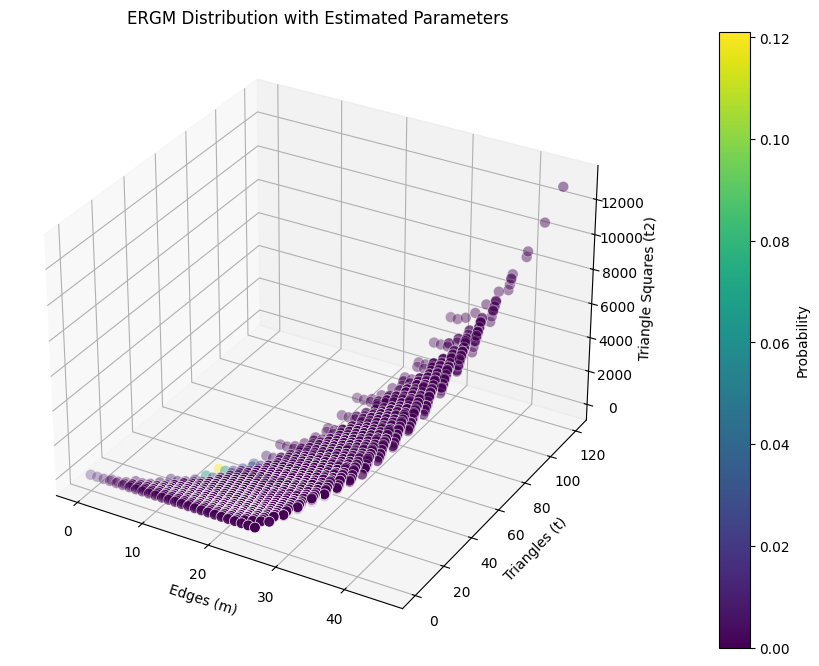

In [16]:
def plot_distribution(alpha, beta, gamma, delta, exact_dist):
    alpha, beta, gamma, delta = map(float, (alpha, beta, gamma, delta))
    data = np.array([[m, t, t2, count] for (m, t, t2), count in exact_dist.items()], dtype=np.float64)
    m_arr, t_arr, t2_arr, count_arr = data[:, 0], data[:, 1], data[:, 2], data[:, 3]
    log_counts = np.log(count_arr)
    
    log_probs = log_counts + alpha * np.ones_like(m_arr) - beta * m_arr - gamma * t_arr - delta * t2_arr
    probs = np.exp(log_probs)
    print(f"Sum of probabilities: {np.sum(probs):.4f}")

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(m_arr, t_arr, t2_arr, 
                            c=probs, cmap='viridis', 
                            s=60, edgecolors='w', linewidth=0.5)
    ax.set_xlabel('Edges (m)')
    ax.set_ylabel('Triangles (t)')
    ax.set_zlabel('Triangle Squares (t2)')
    plt.colorbar(scatter, label='Probability', pad=0.1)
    plt.title('ERGM Distribution with Estimated Parameters')
    plt.show()
    
plot_distribution(params[0], params[1], params[2], params[3], exact_dist)


Sum of probabilities: 1.0000


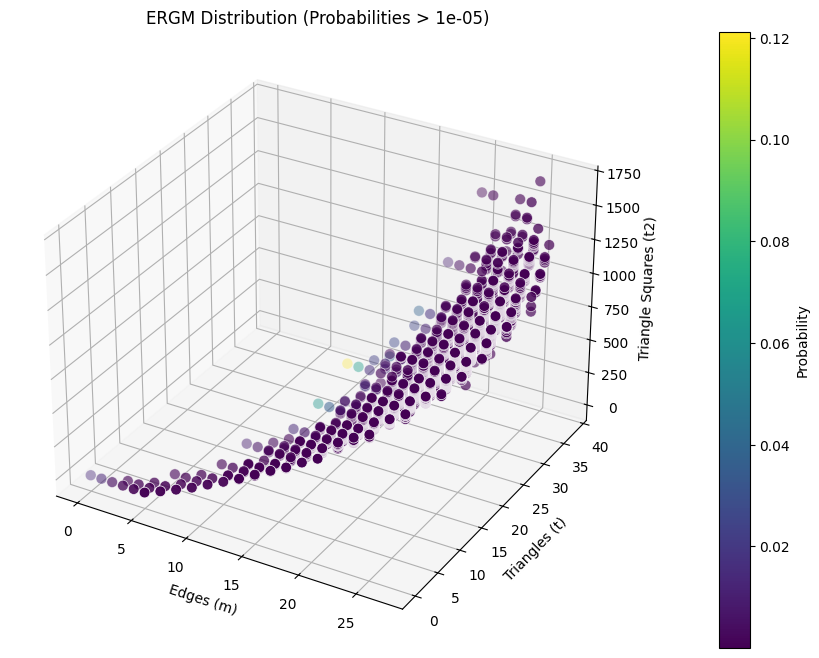

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def plot_distribution_above_threshold(alpha, beta, gamma, delta, exact_dist, threshold):
    alpha, beta, gamma, delta = map(float, (alpha, beta, gamma, delta))
    data = np.array([[m, t, t2, count] for (m, t, t2), count in exact_dist.items()], dtype=np.float64)
    m_arr, t_arr, t2_arr, count_arr = data[:, 0], data[:, 1], data[:, 2], data[:, 3]
    log_counts = np.log(count_arr)
    
    log_probs = log_counts + alpha * np.ones_like(m_arr) - beta * m_arr - gamma * t_arr - delta * t2_arr
    probs = np.exp(log_probs)
    print(f"Sum of probabilities: {np.sum(probs):.4f}")

    mask = probs > threshold

    m_filtered = m_arr[mask]
    t_filtered = t_arr[mask]
    t2_filtered = t2_arr[mask]
    probs_filtered = probs[mask]
    # ----------------------------------------------------------

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    

    scatter = ax.scatter(m_filtered, t_filtered, t2_filtered, 
                         c=probs_filtered, cmap='viridis', 
                         s=60, edgecolors='w', linewidth=0.5, 
                         ) 
                         
    ax.set_xlabel('Edges (m)')
    ax.set_ylabel('Triangles (t)')
    ax.set_zlabel('Triangle Squares (t2)')
    
    plt.colorbar(scatter, label='Probability', pad=0.1)
    plt.title(f'ERGM Distribution (Probabilities > {threshold})')
    plt.show()

plot_distribution_above_threshold(params[0], params[1], params[2], params[3], exact_dist, threshold=1e-5)

In [29]:
#generate watts strogratz graph as target 
import networkx as nx
G = nx.watts_strogatz_graph(n=10, k=4, p=0.1)
m = G.number_of_edges()
t = sum(nx.triangles(G).values()) // 3
t2 = sum(count**2 for count in nx.triangles(G).values())
print(f"Target graph: m={m}, t={t}, t2={t2}")

Target graph: m=20, t=9, t2=81


1. fast SciPy pre-solve
Guesses: alpha=-54.0334, beta=1.0925, gamma=-10.9305, delta=0.5922

2. mpmath solver...
Total Probability: 1.0000000000000000000000332447909312262637090761123
Expected Edges: 20.000000000000000000000675354294622528342711961346
Expected Triangles: 9.0000000000000000000003165710778809520236610868793
Expected Triangle Squares: 81.000000000000000000003061082274713225157255872006
Sum of probabilities: 1.0000


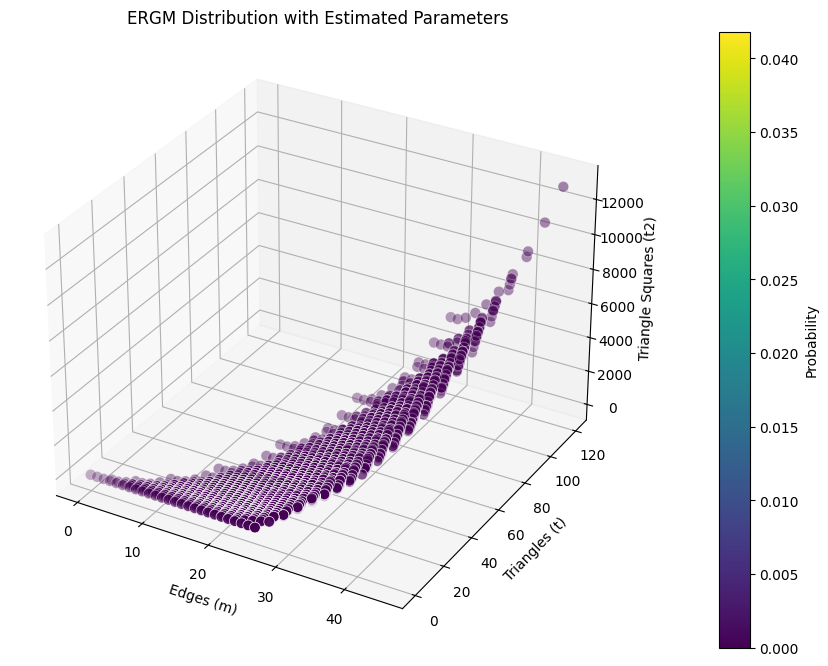

In [30]:
params = find_ergm_hybrid(10, m, t, t2, exact_dist)
verify_ergm_params(params[0], params[1], params[2], params[3], exact_dist)
plot_distribution(params[0], params[1], params[2], params[3], exact_dist)


Sum of probabilities: 1.0000


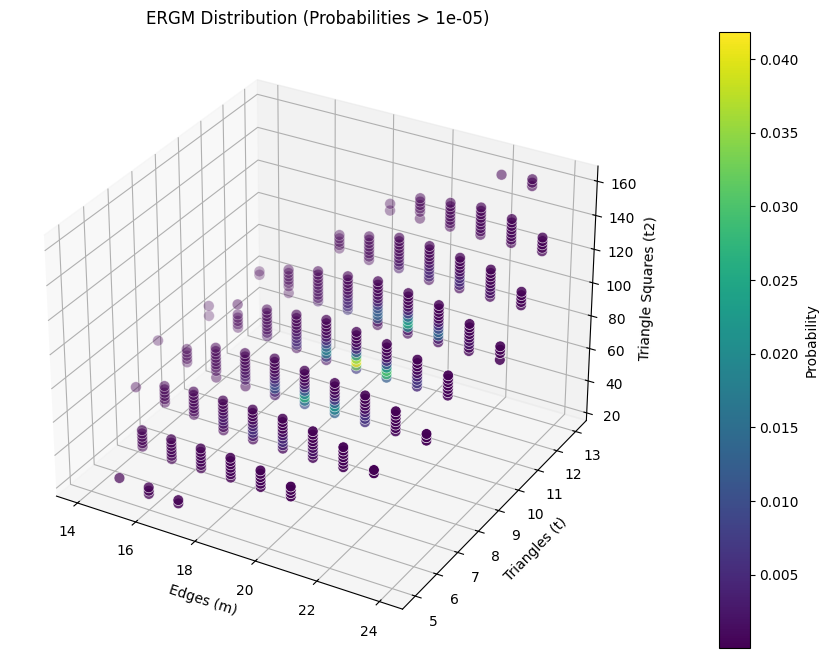

In [33]:
plot_distribution_above_threshold(params[0], params[1], params[2], params[3], exact_dist, threshold=1e-5)

20 9 81
Sum of probabilities: 1.0000


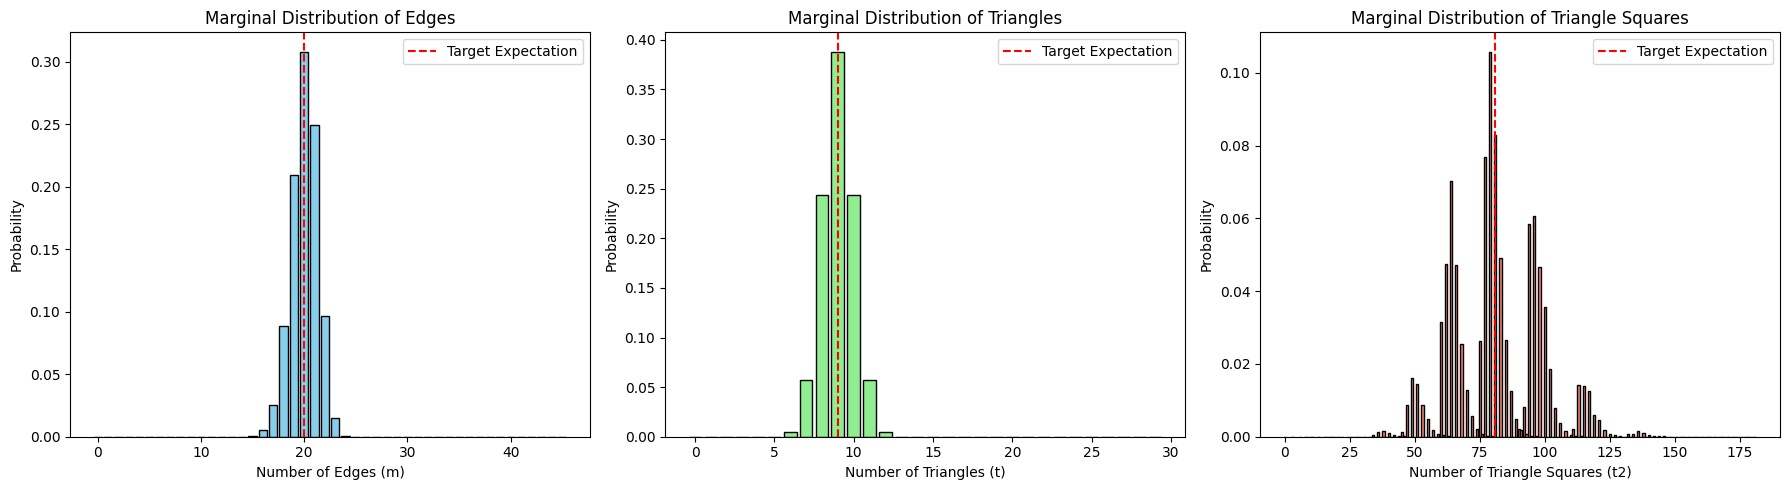

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def plot_marginal_distributions(alpha, beta, gamma, delta, exact_dist):
    print(m,t,t2)
    alpha, beta, gamma, delta = map(float, (alpha, beta, gamma, delta))
    
    # Extract data
    data = np.array([[m, t, t2, count] for (m, t, t2), count in exact_dist.items()], dtype=np.float64)
    m_arr, t_arr, t2_arr, count_arr = data[:, 0], data[:, 1], data[:, 2], data[:, 3]
    
    # Calculate macro-state probabilities
    log_counts = np.log(count_arr)
    log_probs = log_counts + alpha - beta * m_arr - gamma * t_arr - delta * t2_arr
    probs = np.exp(log_probs)
    
    print(f"Sum of probabilities: {np.sum(probs):.4f}")

    # Calculate Marginal Distribution for Edges (m)
    unique_m = np.unique(m_arr)
    marginal_m = [np.sum(probs[m_arr == m]) for m in unique_m]

    # Calculate Marginal Distribution for Triangles (t)
    unique_t = np.unique(t_arr)
    marginal_t = [np.sum(probs[t_arr == t]) for t in unique_t]

    unique_t2 = np.unique(t2_arr)
    marginal_t2 = [np.sum(probs[t2_arr == t2]) for t2 in unique_t2]
    # Create subplots for the marginals
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Marginal Edges
    ax1.bar(unique_m, marginal_m, color='skyblue', edgecolor='black')
    ax1.set_xlabel('Number of Edges (m)')
    ax1.set_ylabel('Probability')
    ax1.set_title('Marginal Distribution of Edges')
    ax1.axvline(x=m, color='red', linestyle='--', label='Target Expectation')
    ax1.legend()

    # Plot 2: Marginal Triangles
    t_range = 20
    t_mask = (unique_t >= t - t_range) & (unique_t <= t + t_range)
    
    ax2.bar(unique_t[t_mask], np.array(marginal_t)[t_mask], color='lightgreen', edgecolor='black')
    ax2.set_xlabel('Number of Triangles (t)')
    ax2.set_ylabel('Probability')
    ax2.set_title('Marginal Distribution of Triangles')
    ax2.axvline(x=t, color='red', linestyle='--', label='Target Expectation')
    ax2.legend()

    # Plot 3: Marginal Triangle Squares
    #i want to plot a restricted range of t2 values around the target expectation to better visualize the distribution
    t2_range = 100  # Define the range around the target expectation
    t2_mask = (unique_t2 >= t2 - t2_range) & (unique_t2 <= t2 + t2_range)
    ax3.bar(unique_t2[t2_mask], np.array(marginal_t2)[t2_mask], color='salmon', edgecolor='black')
    ax3.set_xlabel('Number of Triangle Squares (t2)')
    ax3.set_ylabel('Probability')
    ax3.set_title('Marginal Distribution of Triangle Squares')
    ax3.axvline(x=t2, color='red', linestyle='--', label='Target Expectation')
    ax3.legend()
    
    plt.tight_layout()
    plt.show()

# Call the function
plot_marginal_distributions(params[0], params[1], params[2], params[3], exact_dist)

In [1]:
import networkx as nx
import numpy as np

class graphWithComplement:
    def __init__(self, n, p=None):
        self.n = n
        self.half_of_all_edges = n*(n-1)//4
        if p is None:
            self.graph = nx.empty_graph(n)
            self.complement = nx.complete_graph(n)
        else:
            self.graph = nx.fast_gnp_random_graph(n, p)
            self.complement = nx.complement(self.graph)

        self.node_triangles = np.zeros(n, dtype=int)
        triangles_dict = nx.triangles(self.graph)
        for i in range(n):
            self.node_triangles[i] = triangles_dict[i]

    def get_common_neighbors(self, u, v, m=None):
        """Returns an iterable of common neighbors, optimized for density."""
        if m is None or m < self.half_of_all_edges:
            return set(nx.common_neighbors(self.graph, u, v))
        else:
            not_common = self.complement.adj[u].keys() | self.complement.adj[v].keys()
            return set(self.graph.nodes()) - {u, v} - not_common

    def number_of_common_neighbors(self, u, v, m=None):
        return len(self.get_common_neighbors(u, v, m))

    def get_delta_sum_sq_triangles(self, u, v, is_edge, common_nodes):
        """Calculates the change in sum(t_i^2) if edge (u,v) is toggled."""
        c = len(common_nodes)
        if c == 0:
            return 0
            
        tu = self.node_triangles[u]
        tv = self.node_triangles[v]
        sum_tw = sum(self.node_triangles[w] for w in common_nodes)
        
        if not is_edge:  # Adding an edge
            return 2 * c * (tu + tv + c) + 2 * sum_tw + c
        else:            # Removing an edge
            return -2 * c * (tu + tv - c) - 2 * sum_tw + c

    def add_edge(self, u, v, common_nodes=None):
        if common_nodes is None:
            common_nodes = self.get_common_neighbors(u, v)
            
        c = len(common_nodes)
        self.node_triangles[u] += c
        self.node_triangles[v] += c
        for w in common_nodes:
            self.node_triangles[w] += 1
            
        self.graph.add_edge(u, v)
        self.complement.remove_edge(u, v)

    def remove_edge(self, u, v, common_nodes=None):
        if common_nodes is None:
            common_nodes = self.get_common_neighbors(u, v)
            
        c = len(common_nodes)
        self.node_triangles[u] -= c
        self.node_triangles[v] -= c
        for w in common_nodes:
            self.node_triangles[w] -= 1

        self.graph.remove_edge(u, v)
        self.complement.add_edge(u, v)

    def has_edge(self, u, v):
        return self.graph.has_edge(u, v)

In [2]:
import networkx as nx
import numpy as np
import itertools

# --- 1. Your Original Class ---
class graphWithComplementOriginal:
    def __init__(self, n, p=None):
        self.n = n
        self.half_of_all_edges = n*(n-1)//4
        if p is None:
            self.graph = nx.empty_graph(n)
            self.complement = nx.complete_graph(n)
        else:
            self.graph = nx.fast_gnp_random_graph(n, p)
            self.complement = nx.complement(self.graph)

    def number_of_common_neighbors(self, u, v, m=None):
        if m is None or m < self.half_of_all_edges:
            # Added list() here to prevent TypeError: object of type 'generator' has no len()
            return len(list(nx.common_neighbors(self.graph, u, v)))
        else:
            # Your original dense math
            return self.n - 2 - len((self.complement.adj[u].keys() | self.complement.adj[v].keys()) - {u,v})

# --- 2. The Modified Class ---
class graphWithComplementModified:
    def __init__(self, n, p=None):
        self.n = n
        self.half_of_all_edges = n*(n-1)//4
        if p is None:
            self.graph = nx.empty_graph(n)
            self.complement = nx.complete_graph(n)
        else:
            self.graph = nx.fast_gnp_random_graph(n, p)
            self.complement = nx.complement(self.graph)

    def get_common_neighbors(self, u, v, m=None):
        if m is None or m < self.half_of_all_edges:
            return set(nx.common_neighbors(self.graph, u, v))
        else:
            # The new dense set logic
            not_common = self.complement.adj[u].keys() | self.complement.adj[v].keys()
            return set(self.graph.nodes()) - {u, v} - not_common

    def number_of_common_neighbors(self, u, v, m=None):
        return len(self.get_common_neighbors(u, v, m))

# --- 3. The Direct Comparison Test ---
def test_classes_side_by_side():
    n = 500
    
    # Test p=0.2 (sparse, triggers the 'if' branch) 
    # Test p=0.8 (dense, triggers the 'else' branch)
    for p in [0.2, 0.8]:
        # Generate a baseline graph
        baseline = nx.fast_gnp_random_graph(n, p)
        m = baseline.number_of_edges()
        
        # Initialize both classes
        orig_G = graphWithComplementOriginal(n)
        mod_G = graphWithComplementModified(n)
        
        # Sync their internal state perfectly
        orig_G.graph, mod_G.graph = baseline.copy(), baseline.copy()
        orig_G.complement = nx.complement(baseline)
        mod_G.complement = nx.complement(baseline)
        
        threshold = orig_G.half_of_all_edges
        print(f"\nTesting density p={p} (Edges: {m}, Threshold: {threshold})")
        print(f"-> This will trigger the '{'if' if m < threshold else 'else'}' branch.")
        
        # Test every single pair of nodes
        matches = 0
        for u, v in itertools.combinations(range(n), 2):
            count_orig = orig_G.number_of_common_neighbors(u, v, m)
            count_mod = mod_G.number_of_common_neighbors(u, v, m)
            
            assert count_orig == count_mod, f"Mismatch at ({u},{v}): Orig={count_orig}, Mod={count_mod}"
            matches += 1
            
        print(f"-> Success! All {matches} node pairs returned identical common neighbor counts.")

if __name__ == "__main__":
    test_classes_side_by_side()


Testing density p=0.2 (Edges: 24799, Threshold: 62375)
-> This will trigger the 'if' branch.
-> Success! All 124750 node pairs returned identical common neighbor counts.


KeyboardInterrupt: 

In [3]:
def run_ergm_chain_history(G, m, t, n, alpha, beta, gamma, delta):
    steps = 100000
    current_m = m
    current_t = t
    
    # Initialize the sum of squared triangles based on the tracked array
    current_t2 = np.sum(G.node_triangles**2)
    
    m_history = []
    t_history = []
    t2_history = []
    
    for _ in range(steps):
        if _ % 1000 == 0:
            print(_)
        i, j = np.random.randint(0, n, 2)
        while i == j: 
            i, j = np.random.randint(0, n, 2)
        
        is_edge = G.has_edge(i, j)
        
        # Fetch actual common neighbors once to use for both counts and formulas
        common_nodes = G.get_common_neighbors(i, j, current_m)
        c = len(common_nodes)
        
        delta_m = -1 if is_edge else 1
        delta_t = -c if is_edge else c 
        delta_t2 = G.get_delta_sum_sq_triangles(i, j, is_edge, common_nodes)
        
        m_prop = current_m + delta_m
        t_prop = current_t + delta_t
        t2_prop = current_t2 + delta_t2
        
        # Include the new parameter (eta) multiplied by the change in S
        dH = beta * delta_m + gamma * delta_t + delta * delta_t2
        
        if np.log(np.random.uniform()) <= dH:
            # Pass common_nodes to avoid recalculating them inside the update
            if is_edge: 
                G.remove_edge(i, j, common_nodes)
            else: 
                G.add_edge(i, j, common_nodes)
            
            current_m = m_prop
            current_t = t_prop
            current_t2 = t2_prop
            
        m_history.append(current_m)
        t_history.append(current_t)
        t2_history.append(current_t2)
        
    return m_history, t_history, t2_history

In [45]:
n=500
G=graphWithComplement(n)
m = G.graph.number_of_edges()
t = sum(G.node_triangles) // 3
m_history, t_history, t2_history = run_ergm_chain_history(G, m, t, n, alpha=0.0, beta=0.1, gamma=0.1, delta=0.01)


0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000


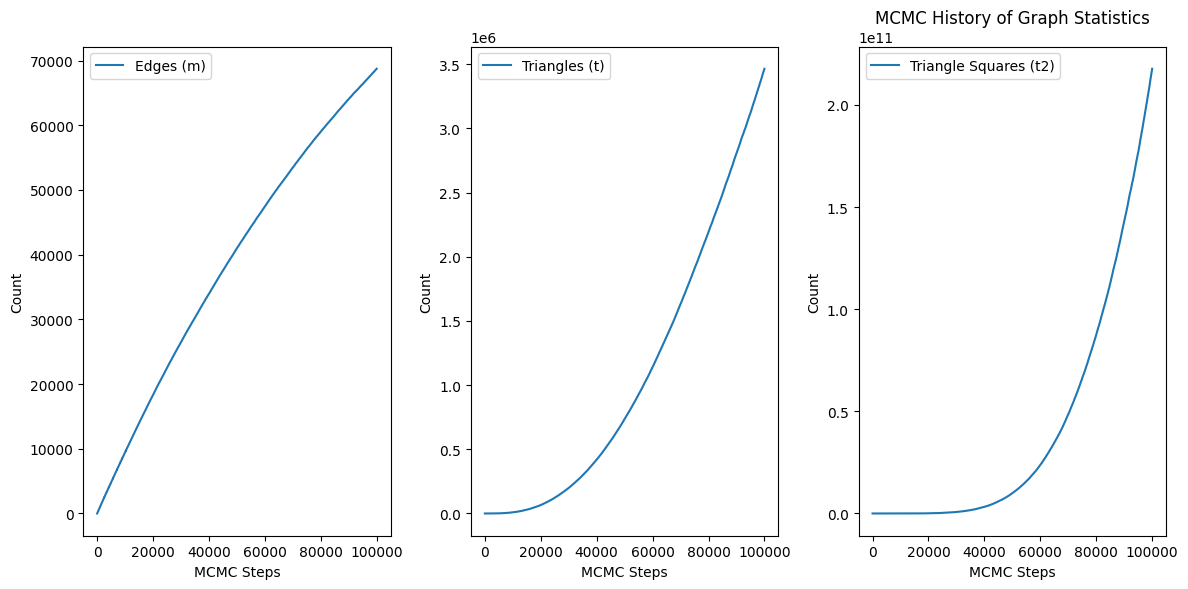

In [46]:

#plot histories 
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
#plot on separate subplots to better visualize the trends
plt.plot(m_history, label='Edges (m)')
plt.xlabel('MCMC Steps')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(t_history, label='Triangles (t)')
plt.xlabel('MCMC Steps')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(t2_history, label='Triangle Squares (t2)')
plt.xlabel('MCMC Steps')
plt.ylabel('Count')
plt.legend()
plt.title('MCMC History of Graph Statistics')
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
import time
import numpy as np
import networkx as nx

n = 500
alpha = -2.2  # Set to negative to match your previous -(a * delta_m) logic
gamma = 0.0   # Set your gamma value for t2 here
G = graphWithComplement(n)

m = 0
t = 0
t2 = 0 # Initialized for an empty graph

max_its = 800000
check_interval = 50000
tol = 0.01  # relative convergence tolerance

up_edges = []
up_tris = []
up_t2s = []

down_edges = []
down_tris = []
down_t2s = []

beta_vals = np.linspace(0, 0.1, 20)

prev_avg_edges = None
prev_avg_tris = None
prev_avg_t2 = None

# --- UPSWEEP ---
for beta in beta_vals:
    start_time = time.time()
    converged = False
    iteration = 0

    while iteration < max_its and not converged:
        edges_sum = 0
        tris_sum = 0
        t2_sum = 0

        for _ in range(check_interval):
            i, j = np.random.randint(0, n, 2)
            while i == j:
                i, j = np.random.randint(0, n, 2)
            
            # 1. Evaluate current state
            is_edge = G.has_edge(i, j)
            common_nodes = G.get_common_neighbors(i, j, m)
            c = len(common_nodes)

            # 2. Calculate potential deltas
            if is_edge:
                delta_m = -1
                delta_t = -c
            else:
                delta_m = 1
                delta_t = c
                
            delta_t2 = G.get_delta_sum_sq_triangles(i, j, is_edge, common_nodes)

            # 3. Calculate acceptance probability
            dH = alpha * delta_m + beta * delta_t + gamma * delta_t2
            
            # 4. Accept or reject
            if np.log(np.random.uniform()) <= dH:
                if is_edge:
                    G.remove_edge(i, j, common_nodes)
                else:
                    G.add_edge(i, j, common_nodes)
                m += delta_m
                t += delta_t
                t2 += delta_t2

            edges_sum += m
            tris_sum += t
            t2_sum += t2

        iteration += check_interval

        avg_edges = edges_sum / check_interval
        avg_tris = tris_sum / check_interval
        avg_t2 = t2_sum / check_interval

        if prev_avg_edges is not None:
            rel_diff_edges = abs(avg_edges - prev_avg_edges) / (abs(prev_avg_edges) + 1e-9)
            rel_diff_tris = abs(avg_tris - prev_avg_tris) / (abs(prev_avg_tris) + 1e-9)
            rel_diff_t2 = abs(avg_t2 - prev_avg_t2) / (abs(prev_avg_t2) + 1e-9)
            
            if rel_diff_edges < tol and rel_diff_tris < tol and rel_diff_t2 < tol:
                converged = True

        prev_avg_edges = avg_edges
        prev_avg_tris = avg_tris
        prev_avg_t2 = avg_t2

    elapsed = time.time() - start_time
    print(f"beta = {beta:.4f}, iters = {iteration}, time = {elapsed:.2f}s, converged = {converged}")
    print(f"   Avg Edges: {avg_edges:.1f}, Avg Tris: {avg_tris:.1f}")

    up_edges.append(avg_edges)
    up_tris.append(avg_tris)
    up_t2s.append(avg_t2)

# --- DOWNSWEEP ---
for beta in reversed(beta_vals):
    start_time = time.time()
    converged = False
    iteration = 0

    while iteration < max_its and not converged:
        edges_sum = 0
        tris_sum = 0
        t2_sum = 0

        for _ in range(check_interval):
            i, j = np.random.randint(0, n, 2)
            while i == j:
                i, j = np.random.randint(0, n, 2)
            
            # 1. Evaluate current state
            is_edge = G.has_edge(i, j)
            common_nodes = G.get_common_neighbors(i, j, m)
            c = len(common_nodes)

            # 2. Calculate potential deltas
            if is_edge:
                delta_m = -1
                delta_t = -c
            else:
                delta_m = 1
                delta_t = c
                
            delta_t2 = G.get_delta_sum_sq_triangles(i, j, is_edge, common_nodes)

            # 3. Calculate acceptance probability
            dH = alpha * delta_m + beta * delta_t + gamma * delta_t2
            
            # 4. Accept or reject
            if np.log(np.random.uniform()) <= dH:
                if is_edge:
                    G.remove_edge(i, j, common_nodes)
                else:
                    G.add_edge(i, j, common_nodes)
                m += delta_m
                t += delta_t
                t2 += delta_t2

            edges_sum += m
            tris_sum += t
            t2_sum += t2

        iteration += check_interval

        avg_edges = edges_sum / check_interval
        avg_tris = tris_sum / check_interval
        avg_t2 = t2_sum / check_interval

        if prev_avg_edges is not None:
            rel_diff_edges = abs(avg_edges - prev_avg_edges) / (abs(prev_avg_edges) + 1e-9)
            rel_diff_tris = abs(avg_tris - prev_avg_tris) / (abs(prev_avg_tris) + 1e-9)
            rel_diff_t2 = abs(avg_t2 - prev_avg_t2) / (abs(prev_avg_t2) + 1e-9)
            
            if rel_diff_edges < tol and rel_diff_tris < tol and rel_diff_t2 < tol:
                converged = True

        prev_avg_edges = avg_edges
        prev_avg_tris = avg_tris
        prev_avg_t2 = avg_t2

    elapsed = time.time() - start_time
    print(f"beta = {beta:.4f}, iters = {iteration}, time = {elapsed:.2f}s, converged = {converged}")
    print(f"   Avg Edges: {avg_edges:.1f}, Avg Tris: {avg_tris:.1f}, avg t2: {avg_t2}")

    down_edges.append(avg_edges)
    down_tris.append(avg_tris)
    down_t2s.append(avg_t2)

beta = 0.0000, iters = 800000, time = 21.72s, converged = False
   Avg Edges: 12383.6, Avg Tris: 20145.7
beta = 0.0053, iters = 100000, time = 3.28s, converged = True
   Avg Edges: 12486.3, Avg Tris: 20706.5
beta = 0.0105, iters = 150000, time = 4.40s, converged = True
   Avg Edges: 12814.1, Avg Tris: 22720.9
beta = 0.0158, iters = 550000, time = 16.84s, converged = True
   Avg Edges: 13738.6, Avg Tris: 27760.0
beta = 0.0211, iters = 750000, time = 22.16s, converged = True
   Avg Edges: 13968.6, Avg Tris: 29773.9
beta = 0.0263, iters = 400000, time = 11.44s, converged = True
   Avg Edges: 14520.5, Avg Tris: 33627.4
beta = 0.0316, iters = 150000, time = 4.83s, converged = True
   Avg Edges: 14778.9, Avg Tris: 35379.3
beta = 0.0368, iters = 800000, time = 25.47s, converged = False
   Avg Edges: 16868.5, Avg Tris: 53004.8
beta = 0.0421, iters = 500000, time = 18.20s, converged = True
   Avg Edges: 19063.7, Avg Tris: 77788.4
beta = 0.0474, iters = 800000, time = 67.24s, converged = False
 

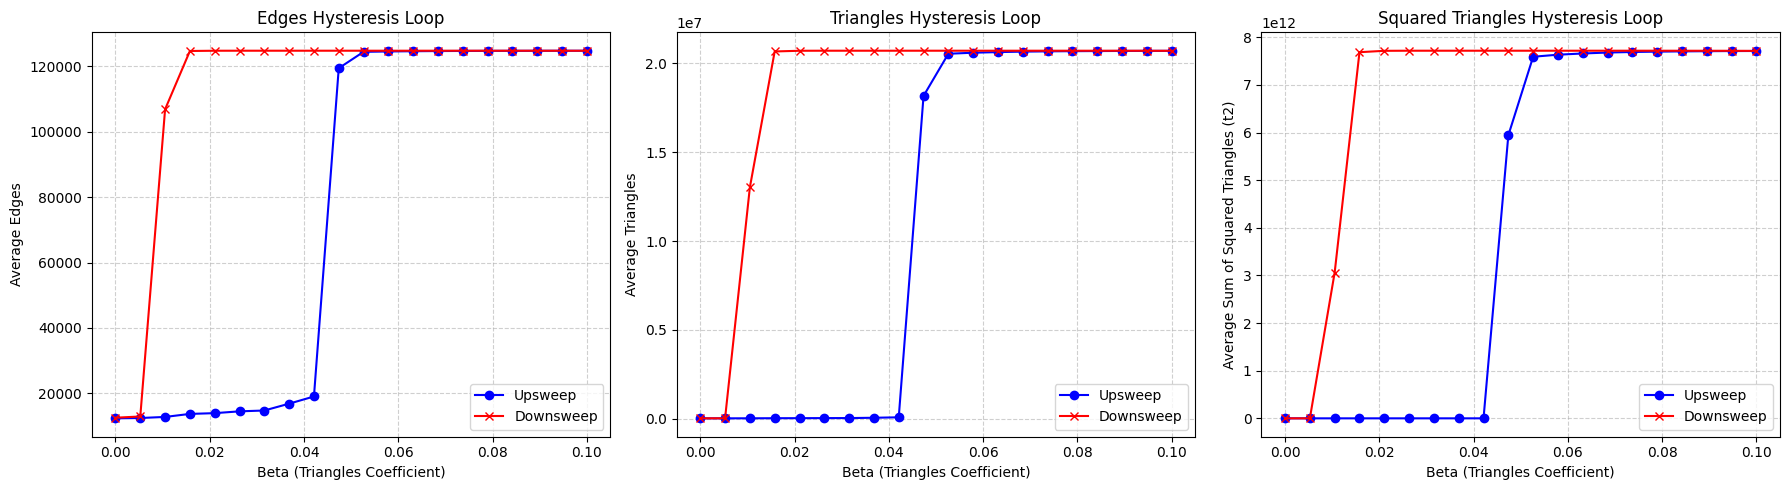

In [8]:
import matplotlib.pyplot as plt

# --- PLOTTING ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Average Edges vs Beta
axs[0].plot(beta_vals, up_edges, label='Upsweep', marker='o', color='blue')
axs[0].plot(beta_vals[::-1], down_edges, label='Downsweep', marker='x', color='red')
axs[0].set_xlabel('Beta (Triangles Coefficient)')
axs[0].set_ylabel('Average Edges')
axs[0].set_title('Edges Hysteresis Loop')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

# Plot 2: Average Triangles vs Beta
axs[1].plot(beta_vals, up_tris, label='Upsweep', marker='o', color='blue')
axs[1].plot(beta_vals[::-1], down_tris, label='Downsweep', marker='x', color='red')
axs[1].set_xlabel('Beta (Triangles Coefficient)')
axs[1].set_ylabel('Average Triangles')
axs[1].set_title('Triangles Hysteresis Loop')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()

# Plot 3: Average Squared Triangles vs Beta
axs[2].plot(beta_vals, up_t2s, label='Upsweep', marker='o', color='blue')
axs[2].plot(beta_vals[::-1], down_t2s, label='Downsweep', marker='x', color='red')
axs[2].set_xlabel('Beta (Triangles Coefficient)')
axs[2].set_ylabel('Average Sum of Squared Triangles (t2)')
axs[2].set_title('Squared Triangles Hysteresis Loop')
axs[2].grid(True, linestyle='--', alpha=0.6)
axs[2].legend()

plt.tight_layout()
plt.show()

In [8]:
import time
import numpy as np
import networkx as nx

n = 500
alpha = -2.2  # Set to negative to match your previous -(a * delta_m) logic
gamma = -0.0001   # Set your gamma value for t2 here
G = graphWithComplement(n)

m = 0
t = 0
t2 = 0 # Initialized for an empty graph

max_its = 800000
check_interval = 50000
tol = 0.01  # relative convergence tolerance

up_edges = []
up_tris = []
up_t2s = []

down_edges = []
down_tris = []
down_t2s = []

beta_vals = np.linspace(0, 5, 20)

prev_avg_edges = None
prev_avg_tris = None
prev_avg_t2 = None

# --- UPSWEEP ---
for beta in beta_vals:
    start_time = time.time()
    converged = False
    iteration = 0

    while iteration < max_its and not converged:
        edges_sum = 0
        tris_sum = 0
        t2_sum = 0

        for _ in range(check_interval):
            i, j = np.random.randint(0, n, 2)
            while i == j:
                i, j = np.random.randint(0, n, 2)
            
            # 1. Evaluate current state
            is_edge = G.has_edge(i, j)
            common_nodes = G.get_common_neighbors(i, j, m)
            c = len(common_nodes)

            # 2. Calculate potential deltas
            if is_edge:
                delta_m = -1
                delta_t = -c
            else:
                delta_m = 1
                delta_t = c
                
            delta_t2 = G.get_delta_sum_sq_triangles(i, j, is_edge, common_nodes)

            # 3. Calculate acceptance probability
            dH = alpha * delta_m + beta * delta_t + gamma * delta_t2
            
            # 4. Accept or reject
            if np.log(np.random.uniform()) <= dH:
                if is_edge:
                    G.remove_edge(i, j, common_nodes)
                else:
                    G.add_edge(i, j, common_nodes)
                m += delta_m
                t += delta_t
                t2 += delta_t2

            edges_sum += m
            tris_sum += t
            t2_sum += t2

        iteration += check_interval

        avg_edges = edges_sum / check_interval
        avg_tris = tris_sum / check_interval
        avg_t2 = t2_sum / check_interval

        if prev_avg_edges is not None:
            rel_diff_edges = abs(avg_edges - prev_avg_edges) / (abs(prev_avg_edges) + 1e-9)
            rel_diff_tris = abs(avg_tris - prev_avg_tris) / (abs(prev_avg_tris) + 1e-9)
            rel_diff_t2 = abs(avg_t2 - prev_avg_t2) / (abs(prev_avg_t2) + 1e-9)
            
            if rel_diff_edges < tol and rel_diff_tris < tol and rel_diff_t2 < tol:
                converged = True

        prev_avg_edges = avg_edges
        prev_avg_tris = avg_tris
        prev_avg_t2 = avg_t2

    elapsed = time.time() - start_time
    print(f"beta = {beta:.4f}, iters = {iteration}, time = {elapsed:.2f}s, converged = {converged}")
    print(f"   Avg Edges: {avg_edges:.1f}, Avg Tris: {avg_tris:.1f}")

    up_edges.append(avg_edges)
    up_tris.append(avg_tris)
    up_t2s.append(avg_t2)

# --- DOWNSWEEP ---
for beta in reversed(beta_vals):
    start_time = time.time()
    converged = False
    iteration = 0

    while iteration < max_its and not converged:
        edges_sum = 0
        tris_sum = 0
        t2_sum = 0

        for _ in range(check_interval):
            i, j = np.random.randint(0, n, 2)
            while i == j:
                i, j = np.random.randint(0, n, 2)
            
            # 1. Evaluate current state
            is_edge = G.has_edge(i, j)
            common_nodes = G.get_common_neighbors(i, j, m)
            c = len(common_nodes)

            # 2. Calculate potential deltas
            if is_edge:
                delta_m = -1
                delta_t = -c
            else:
                delta_m = 1
                delta_t = c
                
            delta_t2 = G.get_delta_sum_sq_triangles(i, j, is_edge, common_nodes)

            # 3. Calculate acceptance probability
            dH = alpha * delta_m + beta * delta_t + gamma * delta_t2
            
            # 4. Accept or reject
            if np.log(np.random.uniform()) <= dH:
                if is_edge:
                    G.remove_edge(i, j, common_nodes)
                else:
                    G.add_edge(i, j, common_nodes)
                m += delta_m
                t += delta_t
                t2 += delta_t2

            edges_sum += m
            tris_sum += t
            t2_sum += t2

        iteration += check_interval

        avg_edges = edges_sum / check_interval
        avg_tris = tris_sum / check_interval
        avg_t2 = t2_sum / check_interval

        if prev_avg_edges is not None:
            rel_diff_edges = abs(avg_edges - prev_avg_edges) / (abs(prev_avg_edges) + 1e-9)
            rel_diff_tris = abs(avg_tris - prev_avg_tris) / (abs(prev_avg_tris) + 1e-9)
            rel_diff_t2 = abs(avg_t2 - prev_avg_t2) / (abs(prev_avg_t2) + 1e-9)
            
            if rel_diff_edges < tol and rel_diff_tris < tol and rel_diff_t2 < tol:
                converged = True

        prev_avg_edges = avg_edges
        prev_avg_tris = avg_tris
        prev_avg_t2 = avg_t2

    elapsed = time.time() - start_time
    print(f"beta = {beta:.4f}, iters = {iteration}, time = {elapsed:.2f}s, converged = {converged}")
    print(f"   Avg Edges: {avg_edges:.1f}, Avg Tris: {avg_tris:.1f}, avg t2: {avg_t2}")

    down_edges.append(avg_edges)
    down_tris.append(avg_tris)
    down_t2s.append(avg_t2)

beta = 0.0000, iters = 450000, time = 11.57s, converged = True
   Avg Edges: 10634.3, Avg Tris: 12256.2
beta = 0.2632, iters = 300000, time = 9.26s, converged = True
   Avg Edges: 17826.6, Avg Tris: 60684.1
beta = 0.5263, iters = 150000, time = 5.94s, converged = True
   Avg Edges: 23201.4, Avg Tris: 133381.8
beta = 0.7895, iters = 150000, time = 6.97s, converged = True
   Avg Edges: 26879.8, Avg Tris: 207780.6
beta = 1.0526, iters = 150000, time = 7.06s, converged = True
   Avg Edges: 29810.6, Avg Tris: 281792.7
beta = 1.3158, iters = 150000, time = 8.18s, converged = True
   Avg Edges: 32202.4, Avg Tris: 355590.8
beta = 1.5789, iters = 150000, time = 8.26s, converged = True
   Avg Edges: 34289.1, Avg Tris: 429241.0
beta = 1.8421, iters = 100000, time = 6.09s, converged = True
   Avg Edges: 36160.9, Avg Tris: 502843.7
beta = 2.1053, iters = 100000, time = 6.37s, converged = True
   Avg Edges: 37826.8, Avg Tris: 576368.0
beta = 2.3684, iters = 100000, time = 6.05s, converged = True
   

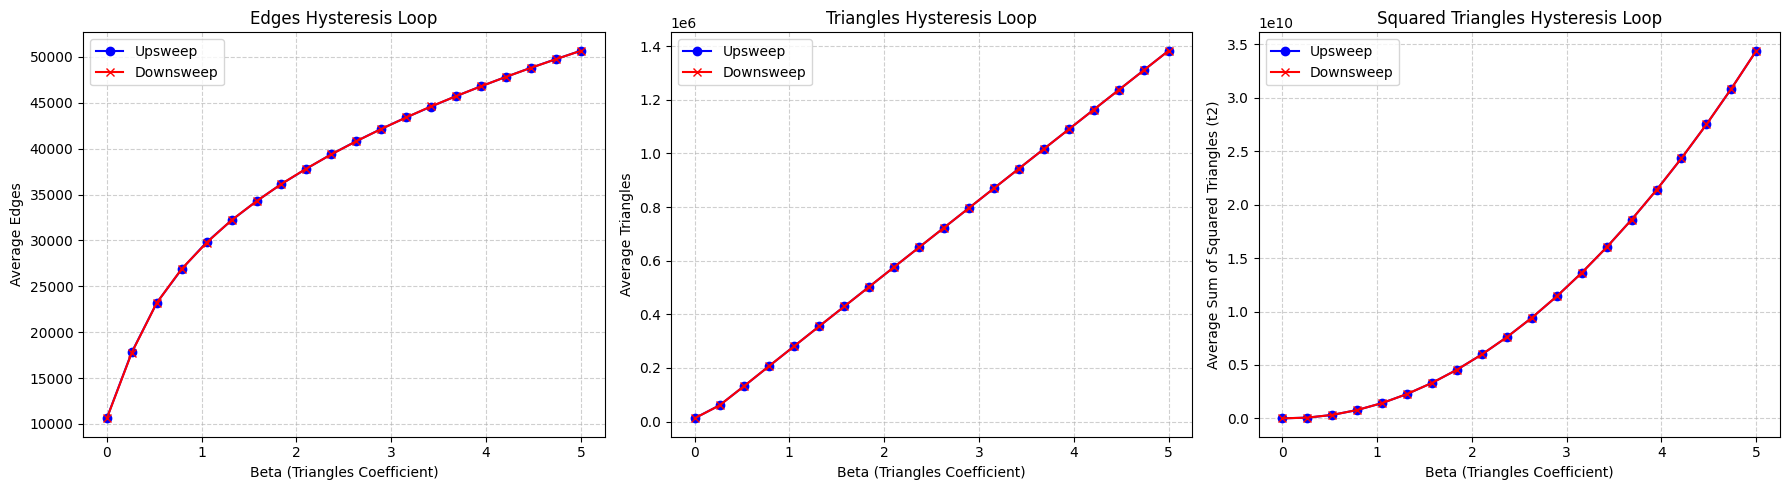

In [9]:
import matplotlib.pyplot as plt

# --- PLOTTING ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Average Edges vs Beta
axs[0].plot(beta_vals, up_edges, label='Upsweep', marker='o', color='blue')
axs[0].plot(beta_vals[::-1], down_edges, label='Downsweep', marker='x', color='red')
axs[0].set_xlabel('Beta (Triangles Coefficient)')
axs[0].set_ylabel('Average Edges')
axs[0].set_title('Edges Hysteresis Loop')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

# Plot 2: Average Triangles vs Beta
axs[1].plot(beta_vals, up_tris, label='Upsweep', marker='o', color='blue')
axs[1].plot(beta_vals[::-1], down_tris, label='Downsweep', marker='x', color='red')
axs[1].set_xlabel('Beta (Triangles Coefficient)')
axs[1].set_ylabel('Average Triangles')
axs[1].set_title('Triangles Hysteresis Loop')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()

# Plot 3: Average Squared Triangles vs Beta
axs[2].plot(beta_vals, up_t2s, label='Upsweep', marker='o', color='blue')
axs[2].plot(beta_vals[::-1], down_t2s, label='Downsweep', marker='x', color='red')
axs[2].set_xlabel('Beta (Triangles Coefficient)')
axs[2].set_ylabel('Average Sum of Squared Triangles (t2)')
axs[2].set_title('Squared Triangles Hysteresis Loop')
axs[2].grid(True, linestyle='--', alpha=0.6)
axs[2].legend()

plt.tight_layout()
plt.show()

In [5]:
import numpy as np

def run_chain(G, m, t, t2, n, alpha, beta, gamma, burn_in=100000, sample_size=500000, sample_interval=100):
    max_m = m
    min_m = m
    max_t = t
    min_t = t
    max_t2 = t2
    min_t2 = t2
    for _ in range(burn_in):
        i, j = np.random.randint(0, n, 2)
        while i == j:
            i, j = np.random.randint(0, n, 2)

        is_edge = G.has_edge(i, j)
        common_nodes = G.get_common_neighbors(i, j, m)
        c = len(common_nodes)

        if is_edge:
            delta_m, delta_t = -1, -c
        else:
            delta_m, delta_t = 1, c
            
        delta_t2 = G.get_delta_sum_sq_triangles(i, j, is_edge, common_nodes)

        dH = -alpha * delta_m - beta * delta_t - gamma * delta_t2
        
        if np.log(np.random.uniform()) <= dH:
            if is_edge:
                G.remove_edge(i, j, common_nodes)
            else:
                G.add_edge(i, j, common_nodes)
            m += delta_m
            t += delta_t
            t2 += delta_t2
            if m > max_m: max_m = m
            if m < min_m: min_m = m
            if t > max_t: max_t = t
            if t < min_t: min_t = t
            if t2 > max_t2: max_t2 = t2
            if t2 < min_t2: min_t2 = t2

    batch_edges = 0
    batch_tris = 0
    batch_t2 = 0
    samples_taken = 0
    
    for step in range(sample_size):
        if step % 100000 == 0:
            print(f"Sampling step {step}/{sample_size}")
        i, j = np.random.randint(0, n, 2)
        while i == j:
            i, j = np.random.randint(0, n, 2)

        is_edge = G.has_edge(i, j)
        common_nodes = G.get_common_neighbors(i, j, m)
        c = len(common_nodes)

        if is_edge:
            delta_m, delta_t = -1, -c
        else:
            delta_m, delta_t = 1, c
            
        delta_t2 = G.get_delta_sum_sq_triangles(i, j, is_edge, common_nodes)

        dH = -alpha * delta_m - beta * delta_t - gamma * delta_t2
        
        if np.log(np.random.uniform()) <= dH:
            if is_edge:
                G.remove_edge(i, j, common_nodes)
            else:
                G.add_edge(i, j, common_nodes)
            m += delta_m
            t += delta_t
            t2 += delta_t2

        if step % sample_interval == 0:
            batch_edges += m
            batch_tris += t
            batch_t2 += t2
            samples_taken += 1

    avg_edges = batch_edges / samples_taken
    avg_tris = batch_tris / samples_taken
    avg_t2 = batch_t2 / samples_taken
    print(f"Sampled Averages: m={avg_edges:.1f}, t={avg_tris:.1f}, t2={avg_t2:.1f}")
    print(f"Ranges during burn-in: m [{min_m}, {max_m}], t [{min_t}, {max_t}], t2 [{min_t2}, {max_t2}]")
    return G, m, t, t2, avg_edges, avg_tris, avg_t2


import numpy as np

def mle_optimize(G_init, target_m, target_t, target_t2, n, max_epochs=150):
    alpha, beta, gamma = 2.0, -2.0, 0.001 
    
    lr_a, lr_b, lr_g = 0.1, 0.1, 0.005 
    
    m_a, v_a = 0.0, 0.0
    m_b, v_b = 0.0, 0.0
    m_g, v_g = 0.0, 0.0
    b1, b2, eps = 0.9, 0.999, 1e-8
    
    G = G_init
    m = G.graph.number_of_edges()
    t = sum(G.node_triangles) // 3
    t2 = np.sum(G.node_triangles**2)
    G_list = []
    
    for epoch in range(max_epochs):        
        current_burn = 200000
        
        G, m, t, t2, avg_m, avg_t, avg_t2 = run_chain(
            G, m, t, t2, n, alpha, beta, gamma, 
            burn_in=current_burn, sample_size=1000000
        )

        G_list.append(G.graph.copy())
        
        grad_a = target_m - avg_m
        grad_b = target_t - avg_t
        grad_g = target_t2 - avg_t2
        
        m_a = b1 * m_a + (1 - b1) * grad_a
        v_a = b2 * v_a + (1 - b2) * (grad_a ** 2)
        m_a_hat = m_a / (1 - b1 ** (epoch + 1))
        v_a_hat = v_a / (1 - b2 ** (epoch + 1))
        alpha -= lr_a * m_a_hat / (np.sqrt(v_a_hat) + eps)

        m_b = b1 * m_b + (1 - b1) * grad_b
        v_b = b2 * v_b + (1 - b2) * (grad_b ** 2)
        m_b_hat = m_b / (1 - b1 ** (epoch + 1))
        v_b_hat = v_b / (1 - b2 ** (epoch + 1))
        beta -= lr_b * m_b_hat / (np.sqrt(v_b_hat) + eps)

        m_g = b1 * m_g + (1 - b1) * grad_g
        v_g = b2 * v_g + (1 - b2) * (grad_g ** 2)
        m_g_hat = m_g / (1 - b1 ** (epoch + 1))
        v_g_hat = v_g / (1 - b2 ** (epoch + 1))
        gamma -= lr_g * m_g_hat / (np.sqrt(v_g_hat) + eps)
        
        gamma = max(1e-6, gamma)
        
        print(f"Epoch {epoch+1}/{max_epochs} | "
              f"Params: a={alpha:.4f}, b={beta:.4f}, g={gamma:.8f}")

    return alpha, beta, gamma, G_list

In [17]:
#watts strogratz graph as target
import networkx as nx
G = nx.watts_strogatz_graph(n=500, k=12, p=0.1)
m = G.number_of_edges()
t = sum(nx.triangles(G).values()) // 3
t2 = sum(count**2 for count in nx.triangles(G).values())
print(f"Target graph: m={m}, t={t}, t2={t2}")

Target graph: m=3000, t=5616, t2=589516


In [18]:
n=500
G_init = graphWithComplement(n,0.1)
m_init = G_init.graph.number_of_edges()
t_init = sum(G_init.node_triangles) // 3
t2_init = np.sum(G_init.node_triangles**2)
alpha, beta, gamma, G_list = mle_optimize(G_init,target_m=m, target_t=t, target_t2=t2, n=500)

Sampled Averages: m=17374.8, t=54844.5, t2=54373736.3
Ranges during burn-in: m [12581, 17446], t [21066, 55422], t2 [8580524, 55624280]
Epoch 1/150 | Params: a=2.1000, b=-1.9000, g=0.00600000
Sampled Averages: m=9982.7, t=9183.7, t2=1549432.9
Ranges during burn-in: m [9882, 17342], t [9073, 54702], t2 [1514457, 54090224]
Epoch 2/150 | Params: a=2.1928, b=-1.8278, g=0.00941619
Sampled Averages: m=8737.3, t=5789.1, t2=621765.9
Ranges during burn-in: m [8623, 9958], t [5650, 9219], t2 [595100, 1564961]
Epoch 3/150 | Params: a=2.2819, b=-1.7717, g=0.01205882
Sampled Averages: m=8072.5, t=4439.9, t2=368665.8
Ranges during burn-in: m [8056, 8710], t [4319, 5765], t2 [348112, 614805]
Epoch 4/150 | Params: a=2.3685, b=-1.7272, g=0.01421154
Sampled Averages: m=7605.5, t=3671.3, t2=254169.6
Ranges during burn-in: m [7576, 8043], t [3574, 4414], t2 [241282, 363196]
Epoch 5/150 | Params: a=2.4530, b=-1.6918, g=0.01601401
Sampled Averages: m=7276.6, t=3192.6, t2=193356.9
Ranges during burn-in: m [7

In [21]:
for e, G in enumerate(G_list):
    print(f"Final graph {e}: m={G.graph.number_of_edges()}, t={sum(G.graph.triangles().values()) // 3}, t2={np.sum(G.graph.triangles().values()**2)}")

AttributeError: 'dict' object has no attribute 'number_of_edges'

In [6]:
import numpy as np
alpha, beta, gamma =(np.float64(5.274833329714777),np.float64(-3.391595167903257),np.float64(0.011696079865063744))

#start 10 graphs and run chain on each to see if there is degeneracy

n = 500
num_graphs = 11
results = []
for i in range(num_graphs):
    p = 0.1*i
    G = graphWithComplement(n, p)
    m = G.graph.number_of_edges()
    t = sum(G.node_triangles) // 3
    t2 = np.sum(G.node_triangles**2)

    G, m, t, t2, avg_m, avg_t, avg_t2 = run_chain(
        G, m, t, t2, n, alpha, beta, gamma, 
        burn_in=1000000, sample_size=10000000
    )

    results.append((avg_m, avg_t, avg_t2))
    print(f"Graph {i+1} p={p:.2f} | Avg m: {avg_m:.1f}, Avg t: {avg_t:.1f}, Avg t2: {avg_t2:.1f}")


Sampling step 0/10000000
Sampling step 100000/10000000
Sampling step 200000/10000000
Sampling step 300000/10000000
Sampling step 400000/10000000
Sampling step 500000/10000000
Sampling step 600000/10000000
Sampling step 700000/10000000
Sampling step 800000/10000000
Sampling step 900000/10000000
Sampling step 1000000/10000000
Sampling step 1100000/10000000
Sampling step 1200000/10000000
Sampling step 1300000/10000000
Sampling step 1400000/10000000
Sampling step 1500000/10000000
Sampling step 1600000/10000000
Sampling step 1700000/10000000
Sampling step 1800000/10000000
Sampling step 1900000/10000000
Sampling step 2000000/10000000
Sampling step 2100000/10000000
Sampling step 2200000/10000000
Sampling step 2300000/10000000
Sampling step 2400000/10000000
Sampling step 2500000/10000000
Sampling step 2600000/10000000
Sampling step 2700000/10000000
Sampling step 2800000/10000000
Sampling step 2900000/10000000
Sampling step 3000000/10000000
Sampling step 3100000/10000000
Sampling step 3200000/1

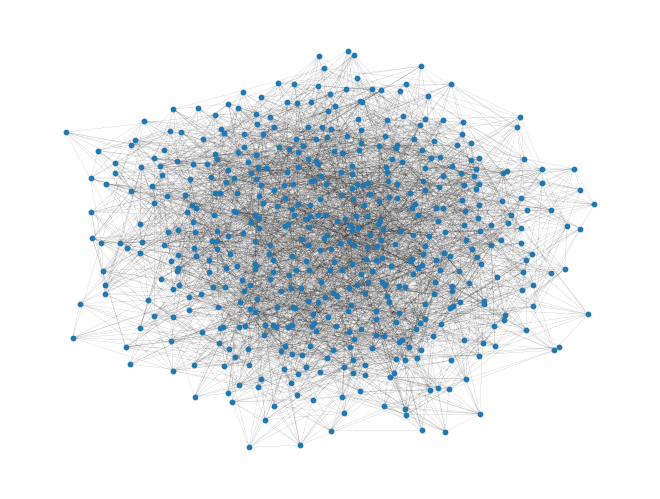

In [26]:
nx.draw(G.graph, node_size = 10, width=0.05, with_labels=False)

In [ ]:
import numpy as np

def run_chain_fixed_edges(G, t, n, beta, tau, burn_in=100000, sample_size=500000, sample_interval=100):
    max_t = t
    min_t = t
    #sum over nodes i where t_i is the number of triangles a node participates in
    H = beta*sum_i(t_i-tau)**2
    for _ in range(burn_in):
        i, j = np.random.randint(0, n, 2)
        while i == j:
            i, j = np.random.randint(0, n, 2)

        is_edge = G.has_edge(i, j)
        common_nodes = G.get_common_neighbors(i, j, m)
        c = len(common_nodes)

        if is_edge:
            delta_m, delta_t = -1, -c
        else:
            delta_m, delta_t = 1, c
            

        dH = -alpha * delta_m - beta * delta_t - gamma * delta_t2
        
        if np.log(np.random.uniform()) <= dH:
            if is_edge:
                G.remove_edge(i, j, common_nodes)
            else:
                G.add_edge(i, j, common_nodes)
            m += delta_m
            t += delta_t
            t2 += delta_t2
            if m > max_m: max_m = m
            if m < min_m: min_m = m
            if t > max_t: max_t = t
            if t < min_t: min_t = t
            if t2 > max_t2: max_t2 = t2
            if t2 < min_t2: min_t2 = t2

    batch_edges = 0
    batch_tris = 0
    batch_t2 = 0
    samples_taken = 0
    
    for step in range(sample_size):
        if step % 100000 == 0:
            print(f"Sampling step {step}/{sample_size}")
        i, j = np.random.randint(0, n, 2)
        while i == j:
            i, j = np.random.randint(0, n, 2)

        is_edge = G.has_edge(i, j)
        common_nodes = G.get_common_neighbors(i, j, m)
        c = len(common_nodes)

        if is_edge:
            delta_m, delta_t = -1, -c
        else:
            delta_m, delta_t = 1, c
            
        delta_t2 = G.get_delta_sum_sq_triangles(i, j, is_edge, common_nodes)

        dH = -alpha * delta_m - beta * delta_t - gamma * delta_t2
        
        if np.log(np.random.uniform()) <= dH:
            if is_edge:
                G.remove_edge(i, j, common_nodes)
            else:
                G.add_edge(i, j, common_nodes)
            m += delta_m
            t += delta_t
            t2 += delta_t2

        if step % sample_interval == 0:
            batch_edges += m
            batch_tris += t
            batch_t2 += t2
            samples_taken += 1

    avg_edges = batch_edges / samples_taken
    avg_tris = batch_tris / samples_taken
    avg_t2 = batch_t2 / samples_taken
    print(f"Sampled Averages: m={avg_edges:.1f}, t={avg_tris:.1f}, t2={avg_t2:.1f}")
    print(f"Ranges during burn-in: m [{min_m}, {max_m}], t [{min_t}, {max_t}], t2 [{min_t2}, {max_t2}]")
    return G, m, t, t2, avg_edges, avg_tris, avg_t2



In [ ]:
import numpy as np
import networkx as nx

def run_chain_fixed_edges(G, n, beta, gamma, burn_in=100000, sample_size=500000, sample_interval=100):
    # Auto-initialize states directly from the graph to prevent desync
    m = G.graph.number_of_edges()
    t = np.sum(G.node_triangles) // 3
    t2 = np.sum(G.node_triangles ** 2)

    max_t, min_t = t, t
    max_t2, min_t2 = t2, t2

    # Combine burn-in and sampling into a single loop to keep things DRY
    total_steps = burn_in + sample_size
    batch_tris = 0
    batch_t2 = 0
    samples_taken = 0

    for step in range(total_steps):
        if step >= burn_in and (step - burn_in) % 100000 == 0:
            print(f"Sampling step {step - burn_in}/{sample_size}")

        # 1. Select an existing edge to remove
        while True:
            u_r, v_r = np.random.randint(0, n, 2)
            if u_r != v_r and G.has_edge(u_r, v_r): 
                break

        # 2. Select a non-existing edge to add
        while True:
            u_a, v_a = np.random.randint(0, n, 2)
            if u_a != v_a and not G.has_edge(u_a, v_a): 
                break

        # 3. Calculate deltas for removal and apply temporarily
        common_r = G.get_common_neighbors(u_r, v_r, m)
        delta_t2_r = G.get_delta_sum_sq_triangles(u_r, v_r, True, common_r)
        delta_t_r = -len(common_r)
        
        # Apply removal to reach intermediate state 
        G.remove_edge(u_r, v_r, common_r)

        # 4. Calculate deltas for addition from the intermediate state
        common_a = G.get_common_neighbors(u_a, v_a, m)
        delta_t2_a = G.get_delta_sum_sq_triangles(u_a, v_a, False, common_a)
        delta_t_a = len(common_a)

        # 5. Aggregate total deltas 
        delta_t = delta_t_r + delta_t_a
        delta_t2 = delta_t2_r + delta_t2_a

        # 6. Evaluate Hamiltonian difference
        delta_H = beta * delta_t2 - gamma * delta_t
        
        # 7. Metropolis-Hastings check
        if np.log(np.random.uniform()) <= -delta_H:
            # ACCEPT: Add the new edge (the removal is already applied)
            G.add_edge(u_a, v_a, common_a)
            t += delta_t
            t2 += delta_t2
            
            # Track bounds
            if t > max_t: max_t = t
            if t < min_t: min_t = t
            if t2 > max_t2: max_t2 = t2
            if t2 < min_t2: min_t2 = t2
        else:
            # REJECT: Revert the temporary removal to restore original state
            G.add_edge(u_r, v_r, common_r)

        # 8. Sampling
        if step >= burn_in and (step - burn_in) % sample_interval == 0:
            batch_tris += t
            batch_t2 += t2
            samples_taken += 1

    avg_tris = batch_tris / samples_taken
    avg_t2 = batch_t2 / samples_taken
    
    print(f"Sampled Averages: m={m} (fixed), t={avg_tris:.1f}, t2={avg_t2:.1f}")
    print(f"Ranges during run: t [{min_t}, {max_t}], t2 [{min_t2}, {max_t2}]")
    
    return G, m, t, t2, m, avg_tris, avg_t2

In [1]:
import numpy as np

def mle_optimize_fixed_edges(G_init, target_t, target_t2, n, tau, max_epochs=150):
    # Initialize the single beta parameter
    beta = 1.0 
    lr_b = 0.05 
    
    # Adam variables for beta
    m_b, v_b = 0.0, 0.0
    b1, b2, eps = 0.9, 0.999, 1e-8
    
    G = G_init
    G_list = []
    
    # Calculate the target unified statistic S(G)
    # Note: n*tau^2 is constant and cancels out in the gradient, so we can omit it
    target_S = target_t2 - 6 * tau * target_t
    
    for epoch in range(max_epochs):        
        current_burn = 100000
        
        # Run the fixed-edge chain
        G, m, t, t2, avg_m, avg_t, avg_t2 = run_chain_fixed_edges(
            G, n, beta, tau, 
            burn_in=current_burn, sample_size=500000
        )

        G_list.append(G.graph.copy())
        
        # Calculate the average statistic from the chain
        avg_S = avg_t2 - 6 * tau * avg_t
        
        # Gradient is (Target Statistic - Average Statistic)
        grad_b = target_S - avg_S
        
        # Adam Update for Beta
        m_b = b1 * m_b + (1 - b1) * grad_b
        v_b = b2 * v_b + (1 - b2) * (grad_b ** 2)
        m_b_hat = m_b / (1 - b1 ** (epoch + 1))
        v_b_hat = v_b / (1 - b2 ** (epoch + 1))
        
        # Note: If P(G) ~ exp(-beta * S(G)), we subtract the gradient to minimize the difference
        beta -= lr_b * m_b_hat / (np.sqrt(v_b_hat) + eps)

        print(f"Epoch {epoch+1}/{max_epochs} | "
              f"Target S: {target_S:.1f}, Avg S: {avg_S:.1f} | "
              f"Beta: {beta:.6f}")

    return beta, G_list

In [2]:
import networkx as nx
import numpy as np

# --- (Assume graphWithComplement, run_chain_fixed_edges, and mle_optimize_fixed_edges are defined here) ---

def init_custom_graph_from_nx(nx_graph):
    """Helper to convert a standard NetworkX graph into your custom class."""
    n = nx_graph.number_of_nodes()
    # Initialize empty custom graph
    custom_G = graphWithComplement(n)
    
    # Add all edges from the target to the custom graph
    for u, v in nx_graph.edges():
        custom_G.add_edge(u, v)
        
    return custom_G

def fit_watts_strogatz():
    # 1. Define target Watts-Strogatz parameters
    n = 500    # Number of nodes
    k = 12      # Each node is joined with its k nearest neighbors in a ring topology
    p = 0.1    # The probability of rewiring each edge

    print("Generating Target Watts-Strogatz Graph...")
    G_target_nx = nx.watts_strogatz_graph(n, k, p)
    
    # 2. Extract target statistics
    target_m = G_target_nx.number_of_edges()
    
    # Calculate triangles for the target graph
    target_tris_dict = nx.triangles(G_target_nx)
    target_node_triangles = np.array(list(target_tris_dict.values()))
    
    target_t = np.sum(target_node_triangles) // 3
    target_t2 = np.sum(target_node_triangles ** 2)
    
    # Calculate tau: A good default for tau is the average triangles per node in the target
    tau = np.mean(target_node_triangles)
    
    print(f"Target Stats -> m: {target_m}, t: {target_t}, t2: {target_t2}, tau: {tau:.2f}")

    # 3. Create G_init (Erdős-Rényi G(n,m) graph with the EXACT same edge count)
    print("\nInitializing random starting graph G_init...")
    G_init_nx = nx.gnm_random_graph(n, target_m)
    
    # Convert standard NetworkX graph to your custom graphWithComplement class
    G_init = init_custom_graph_from_nx(G_init_nx)

    # 4. Run the MLE Optimizer
    print("\nStarting MLE Optimization...")
    max_epochs = 50 
    
    fitted_beta, graph_history = mle_optimize_fixed_edges(
        G_init=G_init, 
        target_t=target_t, 
        target_t2=target_t2, 
        n=n, 
        tau=tau, 
        max_epochs=max_epochs
    )
    
    print(f"\nOptimization Complete. Final Beta: {fitted_beta:.6f}")
    return fitted_beta, graph_history, G_target_nx

fitted_beta, graph_history, G_target = fit_watts_strogatz()

Generating Target Watts-Strogatz Graph...
Target Stats -> m: 3000, t: 5514, t2: 570360, tau: 33.08

Initializing random starting graph G_init...


NameError: name 'graphWithComplement' is not defined

In [3]:
# compare final graph to target


print(f"Target Graph Stats -> m: {G_target.number_of_edges()}, t: {sum(nx.triangles(G_target).values()) // 3}, t2: {np.sum(np.array(list(nx.triangles(G_target).values())) ** 2)}")

#graph.copy object number_of_edges wont work so we need to convert back to a networkx graph to compare stats
final_graph = graph_history[-1]
# Convert final custom graph back to NetworkX for comparison
n=500
G_final_nx = nx.Graph()
G_final_nx.add_nodes_from(range(n))
for u in range(n):
    for v in final_graph[u]:
        G_final_nx.add_edge(u, v)
print(f"Final Graph Stats -> m: {G_final_nx.number_of_edges()}, t: {sum(nx.triangles(G_final_nx).values()) // 3}, t2: {np.sum(np.array(list(nx.triangles(G_final_nx).values())) ** 2)}")

NameError: name 'G_target' is not defined

m=10 | Sum of probabilities: 1.0000
m=20 | Sum of probabilities: 1.0000
m=30 | Sum of probabilities: 1.0000
m=40 | Sum of probabilities: 1.0000


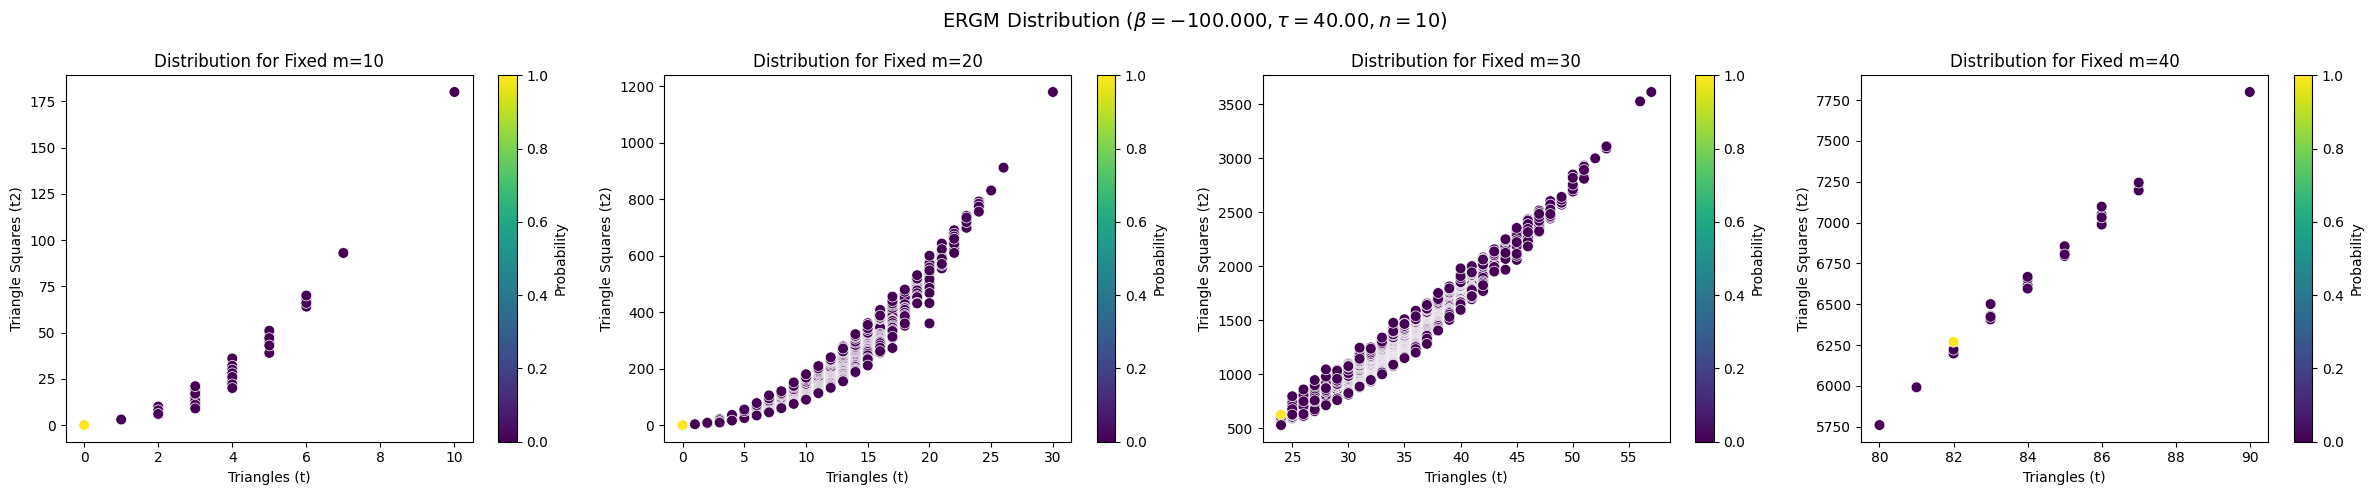

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fixed_m_distributions(beta, tau, n, exact_dist, target_ms):
    beta = float(beta)
    tau = float(tau)
    
    num_plots = len(target_ms)
    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 5), squeeze=False)
    axes = axes.flatten()

    for idx, m_target in enumerate(target_ms):
        ax = axes[idx]
        
        slice_data = [
            (t, t2, count) for (m, t, t2), count in exact_dist.items() if m == m_target
        ]
        
        if not slice_data:
            ax.set_title(f"No data for m={m_target}")
            ax.axis('off')
            continue

        slice_data = np.array(slice_data, dtype=np.float64)
        t_arr, t2_arr, count_arr = slice_data[:, 0], slice_data[:, 1], slice_data[:, 2]
        
        log_counts = np.log(count_arr)
        H = beta * (t2_arr - 6 * tau * t_arr + n * tau**2)
        log_weights = log_counts - H
        
        max_log_weight = np.max(log_weights)
        probs_unnormalized = np.exp(log_weights - max_log_weight)
        Z_m = np.sum(probs_unnormalized) 
        probs = probs_unnormalized / Z_m
        
        print(f"m={m_target} | Sum of probabilities: {np.sum(probs):.4f}")

        scatter = ax.scatter(t_arr, t2_arr, 
                             c=probs, cmap='viridis', 
                             s=60, edgecolors='w', linewidth=0.5)
        
        ax.set_xlabel('Triangles (t)')
        ax.set_ylabel('Triangle Squares (t2)')
        ax.set_title(f'Distribution for Fixed m={m_target}')
        fig.colorbar(scatter, ax=ax, label='Probability', pad=0.05)

    plt.suptitle(rf'ERGM Distribution ($\beta={beta:.3f}, \tau={tau:.2f}, n={n}$)', fontsize=14)
    plt.tight_layout()
    plt.show()

ms = [10, 20, 30, 40]
beta = -100
tau = 40
n=10
plot_fixed_m_distributions(beta, tau, n, exact_dist, ms)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def create_interactive_plot(exact_dist, n, target_m=20):
    # 1. Pre-filter the data for the target_m for instant widget updates
    slice_data = [
        (t, t2, count) for (m, t, t2), count in exact_dist.items() if m == target_m
    ]
    
    if not slice_data:
        print(f"No data found for m={target_m}")
        return

    slice_data = np.array(slice_data, dtype=np.float64)
    t_arr = slice_data[:, 0]
    t2_arr = slice_data[:, 1]
    count_arr = slice_data[:, 2]
    
    log_counts = np.log(count_arr)
    
    # Calculate axis limits to lock the frame
    min_t, max_t = np.min(t_arr), np.max(t_arr)
    min_t2, max_t2 = np.min(t2_arr), np.max(t2_arr)

    # 2. Define the update function that the widgets will call
    def plot_interactive(beta, tau):
        # Calculate probabilities based on current beta and tau
        H = beta * (t2_arr - 6 * tau * t_arr + n * tau**2)
        log_weights = log_counts - H
        
        max_log_weight = np.max(log_weights)
        probs_unnormalized = np.exp(log_weights - max_log_weight)
        probs = probs_unnormalized / np.sum(probs_unnormalized)

        # Plotting
        fig, ax = plt.subplots(figsize=(8, 6))
        
        scatter = ax.scatter(t_arr, t2_arr, 
                             c=probs, cmap='viridis', 
                             s=60, edgecolors='w', linewidth=0.5)
        
        # Lock axes so the dots don't jump around when the probabilities shift
        ax.set_xlim(min_t - max_t*0.05, max_t + max_t*0.05)
        ax.set_ylim(min_t2 - max_t2*0.05, max_t2 + max_t2*0.05)
        
        ax.set_xlabel('Triangles (t)')
        ax.set_ylabel('Triangle Squares (t2)')
        ax.set_title(rf'ERGM Distribution for $m={target_m}$ | $\beta={beta:.2f}$, $\tau={tau:.2f}$')
        
        fig.colorbar(scatter, ax=ax, label='Probability', pad=0.05)
        plt.show()

    # 3. Render the interactive sliders
    interact(plot_interactive, 
             beta=FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.05, description='Beta:'),
             tau=FloatSlider(value=5.0, min=0.0, max=15.0, step=0.5, description='Tau:'))

# Run the interactive plot
create_interactive_plot(exact_dist, n=10, target_m=20)

interactive(children=(FloatSlider(value=0.0, description='Beta:', max=2.0, min=-2.0, step=0.05), FloatSlider(v…